# 02 — Open-Meteo feature EDA and AQI analysis

**Purpose:** combine the active Open-Meteo air-quality and weather-feature files, calculate a the US EPA AQI with pollutant-specific averaging windows, examine seasonality and weather relationships, and save model-ready outputs.

**Important separation:** the long-run weather-trend file is not loaded here. It belongs to notebook 04 and has a different analytical purpose.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '..').resolve()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT))
from src.aqi import calculate_daily_us_aqi
print('Project root:', PROJECT_ROOT)
print('Raw data directory:', RAW_DIR)


Project root: E:\10pearls-internship-2026\development
Raw data directory: E:\10pearls-internship-2026\development\data\raw


In [2]:
def newest(pattern):
    matches = sorted(RAW_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'No file matched {pattern}. Run `python -m src.ingest` first.')
    return matches[-1]

aq_path = newest('karak_aqi_training_open_meteo_hourly_*.csv')
wx_path = newest('karak_weather_features_open_meteo_hourly_*.csv')
aq = pd.read_csv(aq_path, parse_dates=['time']).set_index('time')
wx = pd.read_csv(wx_path, parse_dates=['time']).set_index('time')
aq = aq.drop(columns=['source'], errors='ignore')
wx = wx.drop(columns=['source'], errors='ignore')
master = aq.join(wx, how='inner', rsuffix='_weather').sort_index()
print('Loaded:', aq_path.name)
print('Loaded:', wx_path.name)
print('Master shape:', master.shape)
print('Master range:', master.index.min(), '->', master.index.max())


Loaded: karak_aqi_training_open_meteo_hourly_2022-08-05_to_2026-07-31_20260731_181040.csv
Loaded: karak_weather_features_open_meteo_hourly_2022-08-05_to_2026-07-31_20260731_181049.csv
Master shape: (34968, 19)
Master range: 2022-08-05 00:00:00 -> 2026-07-31 23:00:00


### Finding from the active master frame

The output records how many aligned hours remain after joining the two Open-Meteo products. This is the number available to feature engineering; it is not inferred from a previous run.


In [3]:
pollutant_cols = [c for c in ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index'] if c in master]
weather_cols = [c for c in ['temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 'rain', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m'] if c in master]
agg = {c: 'mean' for c in pollutant_cols + weather_cols}
for c in ['precipitation', 'rain']:
    if c in agg:
        agg[c] = 'sum'
daily = master[pollutant_cols + weather_cols].resample('D').agg(agg)
daily = daily.dropna(subset=['pm2_5'])
daily['hour_count'] = master['pm2_5'].resample('D').count().reindex(daily.index)
print('Daily rows with PM2.5:', len(daily))
print('Median hourly observations per retained day:', daily['hour_count'].median())
print('Days with fewer than 20 observations:', int((daily['hour_count'] < 20).sum()))


Daily rows with PM2.5: 1457
Median hourly observations per retained day: 24.0
Days with fewer than 20 observations: 0


4 years data with 24 reading per day

In [4]:
# Official US EPA AQI from pollutant-specific rolling windows.
# calculate_daily_us_aqi applies EPA unit conversions, truncation, breakpoint
# interpolation, and category assignment. The output is calculated from
# Open-Meteo modeled concentrations, not a station measurement.
aqi_daily = calculate_daily_us_aqi(master[pollutant_cols])
daily = daily.join(aqi_daily, how='left')
daily = daily.dropna(subset=['aqi_us_epa'])
print('US EPA AQI days:', int(daily['aqi_us_epa'].notna().sum()), '/', len(daily))
print('US EPA AQI summary:')
print(daily['aqi_us_epa'].describe().round(1).to_string())
print('Highest modeled AQI day:', daily['aqi_us_epa'].idxmax(), int(daily['aqi_us_epa'].max()))
print('AQI categories:')
print(daily['aqi_category'].value_counts().to_string())


US EPA AQI days: 1457 / 1457
US EPA AQI summary:
count    1457.0
mean       85.0
std        24.9
min        14.6
25%        67.2
50%        80.8
75%        98.4
max       178.1
Highest modeled AQI day: 2024-11-08 00:00:00 178.1


### Finding from the executed AQI calculation

The target is `aqi_us_epa`, calculated with the US EPA AQI method. Each pollutant uses its required averaging window and unit conversion, and the daily value is the maximum valid pollutant sub-index. Open-Meteo supplies modeled concentrations, so this remains a modeled estimate rather than Karak station ground truth.


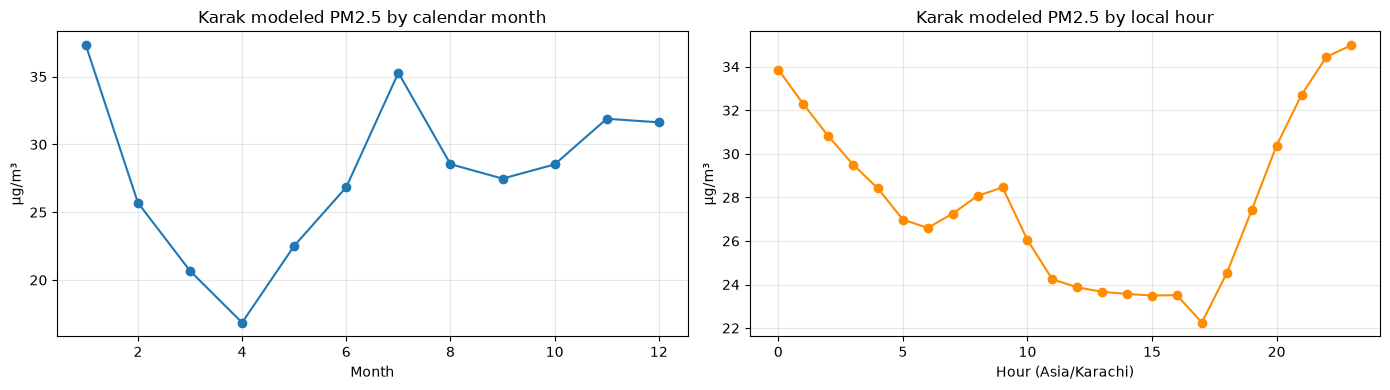

Highest monthly mean: 1 37.32
Lowest monthly mean: 4 16.85
Highest hourly mean: 23 34.99


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
monthly = daily['pm2_5'].groupby(daily.index.month).mean()
hourly = master['pm2_5'].groupby(master.index.hour).mean()
axes[0].plot(monthly.index, monthly.values, marker='o')
axes[0].set(title='Karak modeled PM2.5 by calendar month', xlabel='Month', ylabel='µg/m³')
axes[0].grid(alpha=.3)
axes[1].plot(hourly.index, hourly.values, marker='o', color='darkorange')
axes[1].set(title='Karak modeled PM2.5 by local hour', xlabel='Hour (Asia/Karachi)', ylabel='µg/m³')
axes[1].grid(alpha=.3)
fig.tight_layout()
fig.savefig(PROCESSED_DIR / 'karak_aqi_open_meteo_seasonality.png', dpi=120)
plt.show()
print('Highest monthly mean:', int(monthly.idxmax()), round(monthly.max(), 2))
print('Lowest monthly mean:', int(monthly.idxmin()), round(monthly.min(), 2))
print('Highest hourly mean:', int(hourly.idxmax()), round(hourly.max(), 2))


the highest mean is for month 1 (jan) and is 37.32
the lowest mean is for the month of april and is 16.85
highest mean is for the 11pm and is 34.99

### Finding from seasonality output

The three printed extrema are the interpretation anchors for the figure: they show which month and local hour have the highest modeled PM2.5 in this actual dataset. They should not be explained as causal emissions effects without local observations; weather, dust, and model smoothing remain possible explanations.


In [6]:
available_corr = [c for c in ['pm2_5', 'pm10', 'ozone', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation', 'surface_pressure', 'cloud_cover'] if c in daily]
corr = daily[available_corr].corr()['pm2_5'].drop('pm2_5').sort_values(key=lambda s: s.abs(), ascending=False)
print('Correlations with daily PM2.5 (sorted by absolute value):')
print(corr.round(3).to_string())


Correlations with daily PM2.5 (sorted by absolute value):
pm10                    0.846
relative_humidity_2m    0.241
ozone                   0.159
wind_speed_10m         -0.108
temperature_2m         -0.081
cloud_cover            -0.038
precipitation          -0.029
surface_pressure        0.008


### Finding from weather relationships

The correlation list above is descriptive, not proof of causation. It is nevertheless useful for feature selection because it is computed after daily aggregation from the same aligned Open-Meteo products used by the model.


In [7]:
master['hour_sin'] = np.sin(2 * np.pi * master.index.hour / 24)
master['hour_cos'] = np.cos(2 * np.pi * master.index.hour / 24)
master['month_sin'] = np.sin(2 * np.pi * master.index.month / 12)
master['month_cos'] = np.cos(2 * np.pi * master.index.month / 12)
daily.to_csv(PROCESSED_DIR / 'karak_aqi_open_meteo_daily_features.csv')
master.to_csv(PROCESSED_DIR / 'karak_aqi_open_meteo_hourly_features.csv')
print('Saved hourly features:', len(master))
print('Saved daily features:', len(daily))


Saved hourly features: 34968
Saved daily features: 1457


## 02 decision

The active modeling frame contains only Open-Meteo air quality and Open-Meteo weather. The separate 2000–present weather trend analysis is intentionally kept out of this training frame and is documented in notebook 04.
